In [1]:
import torch
import torch.nn as nn 
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data, Dataset
from torch_geometric.nn import NNConv, global_mean_pool
from torch.nn import Sequential, Linear, ReLU

import pandas as pd
import numpy as np
import os, tqdm

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt

In [13]:
import os
current = os.getcwd()

leakdb = os.path.join(current, "..")
text = os.path.join(leakdb, "txt")

In [2]:
import random
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

In [3]:
def load_scenario_data(scenario_id, base_path=r"D:\LeakDB_full_data\Hanoi"):
    try:
        scenario_path = os.path.join(base_path, f"Scenario-{scenario_id}")
        if not os.path.exists(scenario_path):
            print(f"Scenario {scenario_id} not found.")
            return None
        
        leaks, timestamps = None, None
        demand_path = flow_path = pressure_path = None
        for sub in os.listdir(scenario_path):
            if sub in [f"Scenario-{scenario_id}", f"Scenario-{scenario_id}_info.csv", f"Hanoi_CMH_Scenario-{scenario_id}.inp"]:
                continue
            sub_path = os.path.join(scenario_path, sub)
            if sub == "Demands":
                demand_path = sub_path
            elif sub == "Flows":
                flow_path = sub_path
            elif sub == "Pressures":
                pressure_path = sub_path
            elif sub == "Labels.csv":
                leaks = pd.read_csv(sub_path).drop(columns=["Index"], errors="ignore")
            elif sub == "Timestamps.csv":
                timestamps = pd.read_csv(sub_path).drop(columns=["Index"], errors="ignore")

        if not all([demand_path, flow_path, pressure_path, leaks is not None, timestamps is not None]):
            print(f"Scenario {scenario_id} is incomplete.")
            return None

        df = pd.concat([leaks, timestamps], axis=1, ignore_index=True)
        df.columns = ["Leaks", "Timestamps"]

        def combined_feature_df(path, feature):
            dfs = []
            for file in sorted(os.listdir(path)):
                file_path = os.path.join(path, file)
                if not file.endswith(".csv"):
                    continue
                sub_df = pd.read_csv(file_path).drop(columns="Index", errors="ignore")
                sub_df.columns = [f"{feature}_{file.split('.')[0]}"]
                dfs.append(sub_df)
            return pd.concat(dfs, axis=1, ignore_index=True)

        demand_df = combined_feature_df(demand_path, "demand")
        pressure_df = combined_feature_df(pressure_path, "pressure")
        flow_df = combined_feature_df(flow_path, "flow")

        demand_df.columns = [f"demand_node_{i}" for i in range(1, demand_df.shape[1] + 1)]
        pressure_df.columns = [f"pressure_node_{i}" for i in range(1, pressure_df.shape[1] + 1)]
        flow_df.columns = [f"flow_link_{i}" for i in range(1, flow_df.shape[1] + 1)]

        final_df = pd.concat([demand_df, pressure_df, flow_df, df], axis=1)
        final_df["Leaks"] = final_df["Leaks"].astype(int)
        return final_df

    except Exception as e:
        print(f"Error loading scenario {scenario_id}: {e}")
        return None

In [4]:
def aggregate_nonleak_rows(df, leak_col="Leaks"):
    data_cols = [c for c in df.columns if c != "Timestamps" and c != leak_col]
    out_rows = []
    i = 0
    n = len(df)
    while i < n:
        if df.iloc[i][leak_col] == 1:
            out_rows.append(df.iloc[i][data_cols + [leak_col]].to_dict())
            i += 1
            continue
        j = i
        while j < n and df.iloc[j][leak_col] == 0:
            j += 1
        run_len = j - i
        k = i
        while k + 3 <= j:
            window = df.iloc[k:k+3]
            avg_vals = window[data_cols].mean(axis=0).to_dict()
            avg_vals[leak_col] = 0
            out_rows.append(avg_vals)
            k += 3
        while k < j:
            out_rows.append(df.iloc[k][data_cols + [leak_col]].to_dict())
            k += 1
        i = j
    out_df = pd.DataFrame(out_rows)
    return out_df

In [5]:
def compute_global_mean_std(df_list):
    sum_ = None
    sumsq_ = None
    n_total = 0
    for df in df_list:
        arr = df.drop(columns=["Leaks"]).values.astype(np.float64)
        if sum_ is None:
            sum_ = arr.sum(axis=0)
            sumsq_ = (arr**2).sum(axis=0)
        else:
            sum_ += arr.sum(axis=0)
            sumsq_ += (arr**2).sum(axis=0)
        n_total += arr.shape[0]
    mean = sum_ / n_total
    var = (sumsq_ / n_total) - (mean**2)
    std = np.sqrt(np.maximum(var, 1e-6))
    return mean.astype(np.float32), std.astype(np.float32)

def normalize_df(df, mean, std):
    cols = [c for c in df.columns if c != "Leaks"]
    df2 = df.copy()
    df2[cols] = (df2[cols] - mean) / std
    return df2

In [6]:
def load_edge_index(pipes_path):
    
    edges = []
    
    with open(pipes_path, "r") as file:
        for line in file:
            if line.strip().startswith(";") or not line.strip():
                continue
            
            parts = line.split()
            
            if len(parts) < 3:
                continue
            
            try:
                n1, n2 = int(parts[1]), int(parts[2])
                edges.append([n1 - 1, n2 - 1])
            except:
                continue
            
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    return edge_index

In [7]:
def build_graph_from_row(row, edge_index, num_nodes=32):

    node_feats = []
    for i in range(num_nodes):
        node_feats.append([
            row[f"demand_node_{i+1}"],
            row[f"pressure_node_{i+1}"]
        ])
    x = torch.tensor(node_feats, dtype=torch.float)

    edge_feats = []
    for i in range(edge_index.shape[1]):
        edge_feats.append([row[f"flow_link_{i+1}"]])
    edge_attr = torch.tensor(edge_feats, dtype=torch.float)

    y = torch.tensor([row["Leaks"]], dtype=torch.float)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

In [8]:
class ScenarioGraphDataset(Dataset):
    
    def __init__(self, df_list, edge_index, num_nodes=32, transform=None, pre_transform=None):
        super().__init__(transform=transform, pre_transform=pre_transform)
        self.graphs = []
        for df in tqdm.tqdm(df_list, desc="Building graphs"):
            for _, row in df.iterrows():
                g = build_graph_from_row(row, edge_index, num_nodes)
                self.graphs.append(g)

    def len(self):
        return len(self.graphs)

    def get(self, idx):
        return self.graphs[idx]

In [9]:
class LeakGNN(nn.Module):
    def __init__(self, node_in=2, edge_in=1, hidden1=64, hidden2=32, dropout=0.3):
        super().__init__()
        nn_edge1 = Sequential(Linear(edge_in, 16), ReLU(), Linear(16, node_in * hidden1))
        self.conv1 = NNConv(node_in, hidden1, nn_edge1, aggr='mean')

        nn_edge2 = Sequential(Linear(edge_in, 16), ReLU(), Linear(16, hidden1 * hidden2))
        self.conv2 = NNConv(hidden1, hidden2, nn_edge2, aggr='mean')

        self.lin = Linear(hidden2, 1)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_attr, batch):
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = global_mean_pool(x, batch) 
        x = self.lin(x)
        return torch.sigmoid(x).squeeze(1)

In [10]:
import random

seen = set()
SCENARIO_IDS = []

all_ids = list(range(1, 1000))

while len(SCENARIO_IDS) < 50:
    
    random_id = random.choice(all_ids)
    if random_id not in seen:
        SCENARIO_IDS.append(random_id)
        seen.add(random_id)

In [14]:
def train_gnn_pipeline(
    pipes_path,
    base_path=r"D:\LeakDB_full_data\Hanoi",
    scenario_ids=SCENARIO_IDS,
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1,
    epochs=30,
    batch_size=256,
    lr=1e-3,
    dropout=0.3,
    device=None
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
    all_dfs, valid_ids = [], []
    for sid in tqdm.tqdm(scenario_ids, desc="Loading scenarios"):
        df = load_scenario_data(sid, base_path)
        if df is None or len(df) == 0:
            continue
        if "Timestamps" in df.columns:
            df = df.drop(columns=["Timestamps"])
        #df = aggregate_nonleak_rows(df)
        df.reset_index(drop=True, inplace=True)
        all_dfs.append(df)
        valid_ids.append(sid)

    N = len(all_dfs)
    n_train = int(N * train_ratio)
    n_val = int(N * val_ratio)
    idxs = np.arange(N)
    np.random.shuffle(idxs)
    train_dfs = [all_dfs[i] for i in idxs[:n_train]]
    val_dfs = [all_dfs[i] for i in idxs[n_train:n_train+n_val]]
    test_dfs = [all_dfs[i] for i in idxs[n_train+n_val:]]

    mean, std = compute_global_mean_std(train_dfs)
    
    np.savetxt(os.path.join(text, "mean_gnn.txt"), mean)
    np.savetxt(os.path.join(text, "std_gnn.txt"), std)
    
    train_dfs = [normalize_df(df, mean, std) for df in train_dfs]
    val_dfs = [normalize_df(df, mean, std) for df in val_dfs]
    test_dfs = [normalize_df(df, mean, std) for df in test_dfs]

    edge_index = load_edge_index(pipes_path)
    train_set = ScenarioGraphDataset(train_dfs, edge_index)
    val_set   = ScenarioGraphDataset(val_dfs, edge_index)
    test_set  = ScenarioGraphDataset(test_dfs, edge_index)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_set, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_set, batch_size=batch_size, shuffle=False)

    model = LeakGNN(node_in=2, edge_in=1, dropout=dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.BCELoss()

    best_val_f1 = 0
    history = {"train_loss": [], "val_loss": [], "val_f1": []}

    for epoch in range(1, epochs+1):
        model.train()
        train_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = criterion(out, batch.y)
            opt.zero_grad(); loss.backward(); opt.step()
            train_loss += loss.item() * batch.num_graphs
        train_loss /= len(train_loader.dataset)
        history["train_loss"].append(train_loss)

        model.eval()
        preds_all, labs_all = [], []
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                loss = criterion(out, batch.y)
                val_loss += loss.item() * batch.num_graphs
                preds_all.append(out.cpu().numpy())
                labs_all.append(batch.y.cpu().numpy())
        val_loss /= len(val_loader.dataset)
        preds_all = np.concatenate(preds_all)
        labs_all  = np.concatenate(labs_all)
        pred_labels = (preds_all >= 0.5).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(labs_all, pred_labels, average='binary', zero_division=0)

        history["val_loss"].append(val_loss)
        history["val_f1"].append(f1)
        print(f"Epoch {epoch:02d}/{epochs}  TrainLoss={train_loss:.4f}  ValLoss={val_loss:.4f}  ValF1={f1:.4f}")

        if f1 > best_val_f1:
            best_val_f1 = f1
            torch.save(model.state_dict(), os.path.join(leakdb, "best_leak_gnn.pth"))

    print("Training complete. Best Val F1:", best_val_f1)

    model.load_state_dict(torch.load(os.path.join(leakdb, "best_leak_gnn.pth"), map_location=device))
    model.eval()
    preds_all, labs_all = [], []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            preds_all.append(out.cpu().numpy())
            labs_all.append(batch.y.cpu().numpy())
    preds_all = np.concatenate(preds_all)
    labs_all  = np.concatenate(labs_all)
    pred_labels = (preds_all >= 0.5).astype(int)
    acc = accuracy_score(labs_all, pred_labels)
    p, r, f1, _ = precision_recall_fscore_support(labs_all, pred_labels, average='binary', zero_division=0)
    cm = confusion_matrix(labs_all, pred_labels)

    print(f"\nTest Metrics:\nAcc={acc:.4f}  Precision={p:.4f}  Recall={r:.4f}  F1={f1:.4f}")
    print("Confusion Matrix:\n", cm)

    plt.figure(figsize=(5,4))
    plt.imshow(cm, cmap='Blues', interpolation='nearest')
    plt.title("Test Confusion Matrix (GNN)")
    plt.xlabel("Predicted"); plt.ylabel("True")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i,j], ha='center', va='center',
                     color='white' if cm[i,j] > cm.max()/2 else 'black')
    plt.tight_layout(); plt.show()

    return model, history, (acc, p, r, f1)

Building graphs: 100%|██████████| 5/5 [00:17<00:00,  3.49s/it]


Epoch 01/30  TrainLoss=0.3839  ValLoss=0.2162  ValF1=0.8826
Epoch 02/30  TrainLoss=0.3324  ValLoss=0.2555  ValF1=0.7942
Epoch 03/30  TrainLoss=0.3146  ValLoss=0.3139  ValF1=0.7878
Epoch 04/30  TrainLoss=0.3030  ValLoss=0.2607  ValF1=0.8168
Epoch 05/30  TrainLoss=0.2953  ValLoss=0.3049  ValF1=0.7892
Epoch 06/30  TrainLoss=0.2908  ValLoss=0.2547  ValF1=0.8313
Epoch 07/30  TrainLoss=0.2860  ValLoss=0.3594  ValF1=0.7624
Epoch 08/30  TrainLoss=0.2831  ValLoss=0.3216  ValF1=0.7853
Epoch 09/30  TrainLoss=0.2800  ValLoss=0.3337  ValF1=0.7724
Epoch 10/30  TrainLoss=0.2776  ValLoss=0.2596  ValF1=0.8214
Epoch 11/30  TrainLoss=0.2751  ValLoss=0.2584  ValF1=0.8051
Epoch 12/30  TrainLoss=0.2730  ValLoss=0.2699  ValF1=0.8107
Epoch 13/30  TrainLoss=0.2713  ValLoss=0.2774  ValF1=0.8065
Epoch 14/30  TrainLoss=0.2702  ValLoss=0.2250  ValF1=0.8377
Epoch 15/30  TrainLoss=0.2688  ValLoss=0.2447  ValF1=0.8297
Epoch 16/30  TrainLoss=0.2674  ValLoss=0.3189  ValF1=0.7887
Epoch 17/30  TrainLoss=0.2661  ValLoss=0

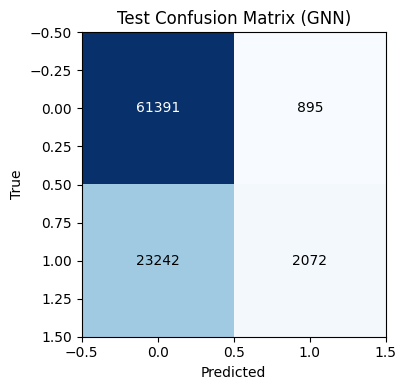

In [15]:
model, history, metrics = train_gnn_pipeline(pipes_path=os.path.join(text, "inp_1_text.txt"), base_path=r"D:\LeakDB_full_data\Hanoi")

In [17]:
from torch_geometric.loader import DataLoader as GeoDataLoader

def test_unseen_scenario_gnn(
    scenario_id,
    pipes_path,
    base_path=r"D:\LeakDB_full_data\Hanoi",
    model_path=os.path.join(leakdb, "best_leak_gnn.pth"),
    mean=None,
    std=None,
    num_nodes=32,
    device=None
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    df = load_scenario_data(scenario_id, base_path)
    if df is None or len(df) == 0:
        print(f"Scenario {scenario_id} could not be loaded.")
        return None

    if "Timestamps" in df.columns:
        df = df.drop(columns=["Timestamps"])
    #df = aggregate_nonleak_rows(df)
    df = df.reset_index(drop=True)

    if mean is None or std is None:
        raise ValueError("mean and std must be provided from training phase.")

    df = normalize_df(df, mean, std)

    edge_index = load_edge_index(pipes_path)
    unseen_set = ScenarioGraphDataset([df], edge_index, num_nodes=num_nodes)
    unseen_loader = GeoDataLoader(unseen_set, batch_size=256, shuffle=False)

    model = LeakGNN(node_in=2, edge_in=1).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    preds_all, labs_all = [], []
    with torch.no_grad():
        for batch in unseen_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            preds_all.append(out.cpu().numpy())
            labs_all.append(batch.y.cpu().numpy())

    preds_all = np.concatenate(preds_all)
    labs_all = np.concatenate(labs_all)
    pred_labels = (preds_all >= 0.5).astype(int)

    acc = accuracy_score(labs_all, pred_labels)
    p, r, f1, _ = precision_recall_fscore_support(labs_all, pred_labels, average="binary", zero_division=0)
    cm = confusion_matrix(labs_all, pred_labels)

    print(f"\nScenario {scenario_id} Results:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {p:.4f}")
    print(f"Recall:    {r:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("Confusion Matrix:\n", cm)

    plt.figure(figsize=(4, 4))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(f"Confusion Matrix - Scenario {scenario_id}")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("True")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max()/2 else 'black')
    plt.show()

    return {
        "scenario_id": scenario_id,
        "accuracy": acc,
        "precision": p,
        "recall": r,
        "f1": f1,
        "confusion_matrix": cm
    }


In [18]:
mean = np.loadtxt(os.path.join(text, "mean_gnn.txt"))
std = np.loadtxt(os.path.join(text, "std_gnn.txt"))

Building graphs: 100%|██████████| 1/1 [00:03<00:00,  3.49s/it]



Scenario 434 Results:
Accuracy:  0.8330
Precision: 0.8992
Recall:    0.3463
F1 Score:  0.5000
Confusion Matrix:
 [[13131   164]
 [ 2762  1463]]


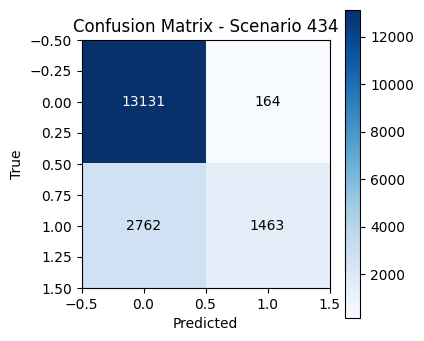

In [20]:
metrics = test_unseen_scenario_gnn(scenario_id=434, mean=mean, std=std, pipes_path=os.path.join(text, "inp_1_text.txt"))

Building graphs: 100%|██████████| 1/1 [00:03<00:00,  3.48s/it]



Scenario 900 Results:
Accuracy:  0.4855
Precision: 1.0000
Recall:    0.0930
F1 Score:  0.1701
Confusion Matrix:
 [[7582    0]
 [9014  924]]


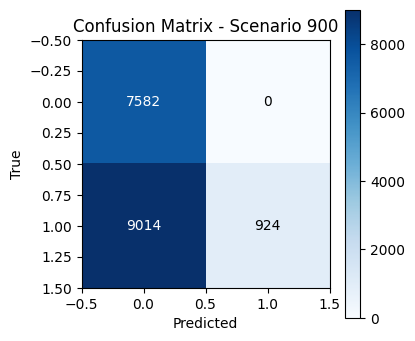

In [21]:
metrics = test_unseen_scenario_gnn(scenario_id=900, mean=mean, std=std, pipes_path=os.path.join(text, "inp_1_text.txt"))

Building graphs: 100%|██████████| 1/1 [00:03<00:00,  3.46s/it]



Scenario 120 Results:
Accuracy:  1.0000
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000
Confusion Matrix:
 [[17520]]


c:\Users\Jash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


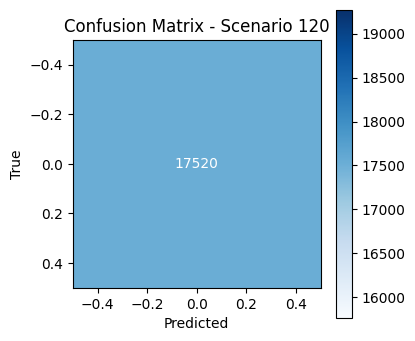

In [22]:
metrics = test_unseen_scenario_gnn(scenario_id=120, mean=mean, std=std, pipes_path=os.path.join(text, "inp_1_text.txt"))

Building graphs: 100%|██████████| 1/1 [00:03<00:00,  3.77s/it]



Scenario 800 Results:
Accuracy:  0.3413
Precision: 1.0000
Recall:    0.2209
F1 Score:  0.3619
Confusion Matrix:
 [[ 2706     0]
 [11541  3273]]


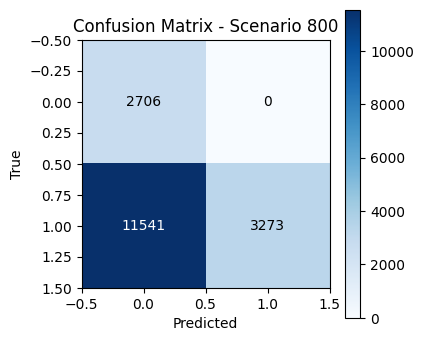

In [23]:
metrics = test_unseen_scenario_gnn(scenario_id=800, mean=mean, std=std, pipes_path=os.path.join(text, "inp_1_text.txt"))